# Univariate Basis Functions: B-Splines

This notebook demonstrates the B-spline basis implementation in `torchtt.functional`. 

B-splines are piecewise polynomial functions widely used for interpolation and approximation. Key features of our implementation:

- **Pure PyTorch**: Full automatic differentiation support
- **Interpolation**: Greville abscissae provide invertible interpolation matrices  
- **Quadrature**: Built-in Gauss-Legendre integration weights

In [15]:
import torch
import torchtt
from torchtt.functional import BSplineBasis
import matplotlib.pyplot as plt

# Use a nice style for plots
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Creating B-Spline Bases of Different Degrees

B-splines of degree $p$ are piecewise polynomials with $C^{p-1}$ continuity at the knots:

- **Degree 0**: Piecewise constant (step functions)
- **Degree 1**: Piecewise linear (hat functions)  
- **Degree 2**: Piecewise quadratic (smooth parabolic arcs)

We create 3 bases on the interval $[0, 1]$ with 8 interior knots.

In [16]:
# Define knot vector
knots = torch.linspace(0, 1, 8)

# Create B-spline bases of degrees 0, 1, and 2
basis_0 = BSplineBasis(knots, deg=0)
basis_1 = BSplineBasis(knots, deg=1)
basis_2 = BSplineBasis(knots, deg=2)

print(f"Degree 0: {basis_0}")
print(f"Degree 1: {basis_1}")
print(f"Degree 2: {basis_2}")

Degree 0: BSplineBasis(n=7, deg=0, interval=(0.0, 1.0))
Degree 1: BSplineBasis(n=8, deg=1, interval=(0.0, 1.0))
Degree 2: BSplineBasis(n=9, deg=2, interval=(0.0, 1.0))


## Visualizing the Basis Functions

Let's plot all basis functions for each degree. We evaluate on a fine grid to see the smooth structure.


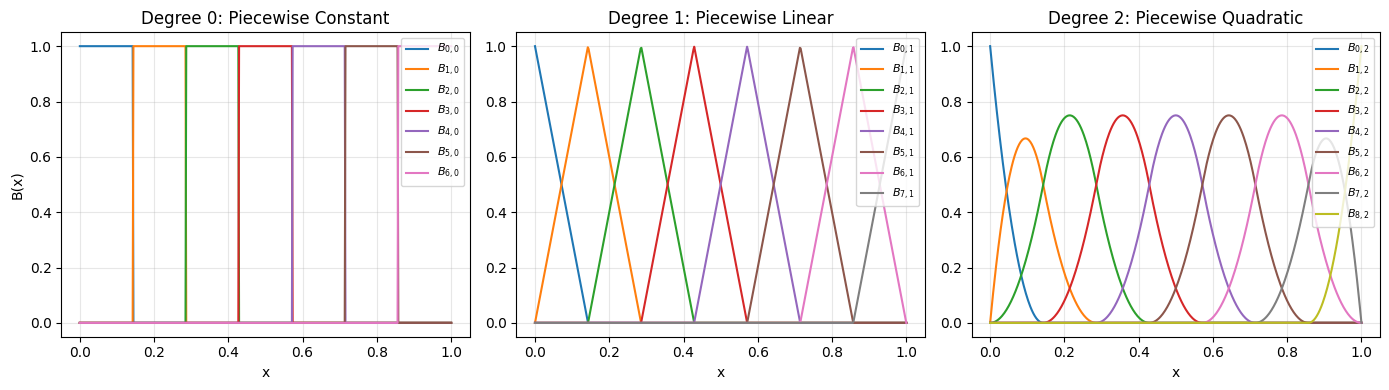

In [17]:
# Fine grid for evaluation (use float64 for consistency with basis internals)
x = torch.linspace(0, 1, 500, dtype=torch.float64)

# Evaluate all bases
B0 = basis_0(x)  # shape: (n0, 500)
B1 = basis_1(x)  # shape: (n1, 500)
B2 = basis_2(x)  # shape: (n2, 500)

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot degree 0 (piecewise constant)
for i in range(B0.shape[0]):
    axes[0].plot(x.numpy(), B0[i].numpy(), label=f'$B_{{{i},0}}$')
axes[0].set_title('Degree 0: Piecewise Constant')
axes[0].set_xlabel('x')
axes[0].set_ylabel('B(x)')
axes[0].legend(loc='upper right', fontsize=8)

# Plot degree 1 (piecewise linear)
for i in range(B1.shape[0]):
    axes[1].plot(x.numpy(), B1[i].numpy(), label=f'$B_{{{i},1}}$')
axes[1].set_title('Degree 1: Piecewise Linear')
axes[1].set_xlabel('x')
axes[1].legend(loc='upper right', fontsize=8)

# Plot degree 2 (piecewise quadratic)
for i in range(B2.shape[0]):
    axes[2].plot(x.numpy(), B2[i].numpy(), label=f'$B_{{{i},2}}$')
axes[2].set_title('Degree 2: Piecewise Quadratic')
axes[2].set_xlabel('x')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


## Interpolation with B-Splines

A function $f(x)$ can be approximated as a linear combination of B-splines:

$$f(x) \approx \sum_{i=0}^{n-1} c_i B_i(x)$$

To find the coefficients $c_i$, we use the **Greville abscissae** (interpolating points) where the basis evaluation matrix is invertible. Given function values $f_i$ at these points, we solve:

$$\mathbf{B} \cdot \mathbf{c} = \mathbf{f}$$


In [18]:
# Define a test function to interpolate
def f(x):
    return torch.sin(2 * torch.pi * x) + 0.5 * torch.cos(4 * torch.pi * x)

# Get interpolating points and basis matrix for degree-2 basis
interp_pts, B_matrix = basis_2.interpolating_points()

print(f"Interpolating points (Greville abscissae): {interp_pts}")
print(f"Basis matrix shape: {B_matrix.shape}")
print(f"Matrix condition number: {torch.linalg.cond(B_matrix):.2f}")


Interpolating points (Greville abscissae): tensor([0.0000, 0.0714, 0.2143, 0.3571, 0.5000, 0.6429, 0.7857, 0.9286, 1.0000],
       dtype=torch.float64)
Basis matrix shape: torch.Size([9, 9])
Matrix condition number: 2.14


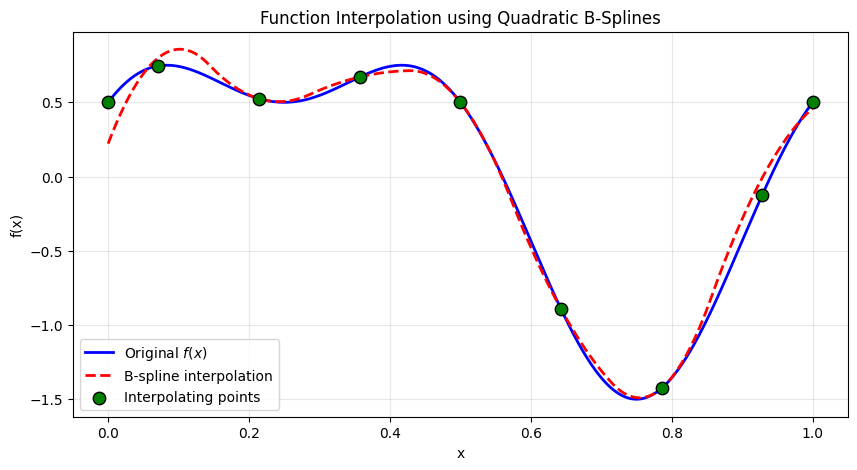

Maximum interpolation error: 0.278475


In [19]:
# Evaluate function at interpolating points
f_vals = f(interp_pts)

# Solve for B-spline coefficients: B @ c = f
coeffs = torch.linalg.solve(B_matrix.T, f_vals)  # B_matrix is (n, n_pts), need transpose

# Reconstruct the function on the fine grid
B2_fine = basis_2(x)  # shape: (n, 500)
f_approx = coeffs @ B2_fine  # shape: (500,)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(x.numpy(), f(x).numpy(), 'b-', linewidth=2, label='Original $f(x)$')
plt.plot(x.numpy(), f_approx.numpy(), 'r--', linewidth=2, label='B-spline interpolation')
plt.scatter(interp_pts.numpy(), f_vals.numpy(), s=80, c='green', zorder=5, 
            label='Interpolating points', edgecolors='black')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function Interpolation using Quadratic B-Splines')
plt.legend()
plt.show()

# Compute interpolation error
error = torch.max(torch.abs(f(x) - f_approx))
print(f"Maximum interpolation error: {error:.6f}")


## Integration Weights of Individual Basis Functions

Each basis provides the integrals of individual basis functions. For B-splines, the integral of each basis function B_i(x) over its support can be computed analytically. These integration weights are useful for various numerical methods and tensor operations.


Number of basis functions: 9
Integration weights (integral of each basis function):
tensor([0.0476, 0.0952, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0952, 0.0476],
       dtype=torch.float64)

Sum of integration weights: 1.0000000000
Expected (interval length): 1.0


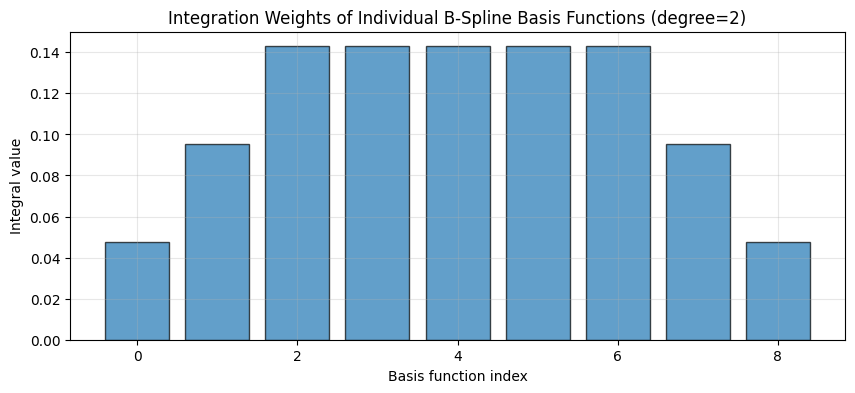

In [20]:
# Get the integration weights for degree-2 basis
int_weights = basis_2.integration_weights()

print(f"Number of basis functions: {basis_2.n}")
print(f"Integration weights (integral of each basis function):")
print(int_weights)
print(f"\nSum of integration weights: {int_weights.sum().item():.10f}")
print(f"Expected (interval length): 1.0")

# Visualize the integration weights
plt.figure(figsize=(10, 4))
plt.bar(range(basis_2.n), int_weights.numpy(), alpha=0.7, edgecolor='black')
plt.xlabel('Basis function index')
plt.ylabel('Integral value')
plt.title('Integration Weights of Individual B-Spline Basis Functions (degree=2)')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [21]:
# Compare integration weights for different degrees
int_weights_0 = basis_0.integration_weights()
int_weights_1 = basis_1.integration_weights()
int_weights_2 = basis_2.integration_weights()

print("Integration weights for different degrees:")
print(f"\nDegree 0 (n={basis_0.n}): sum = {int_weights_0.sum():.6f}")
print(f"Degree 1 (n={basis_1.n}): sum = {int_weights_1.sum():.6f}")
print(f"Degree 2 (n={basis_2.n}): sum = {int_weights_2.sum():.6f}")

# All should sum to the interval length (1.0)
print("\nNote: The sum of integration weights equals the interval length [0, 1] = 1.0")
print("This is a consequence of the partition of unity property of B-splines.")


Integration weights for different degrees:

Degree 0 (n=7): sum = 1.000000
Degree 1 (n=8): sum = 1.000000
Degree 2 (n=9): sum = 1.000000

Note: The sum of integration weights equals the interval length [0, 1] = 1.0
This is a consequence of the partition of unity property of B-splines.


## Automatic Differentiation with B-Splines

One of the key features of our implementation is full PyTorch autograd support. We can compute gradients of any function of the basis values with respect to the input points.

This is particularly useful for:
- Optimization problems
- Learning-based methods
- Sensitivity analysis


In [22]:
# Create input with gradient tracking
x_grad = torch.linspace(0, 1, 200, requires_grad=True, dtype=torch.float64)

# Evaluate basis
B2_grad = basis_2(x_grad)  # shape: (n, 200)

# Compute some scalar function of the basis (e.g., sum of all values)
loss = B2_grad.sum()

# Backpropagate to get gradient w.r.t. input
loss.backward()

print(f"Input shape: {x_grad.shape}")
print(f"Basis output shape: {B2_grad.shape}")
print(f"Gradient shape: {x_grad.grad.shape}")
print(f"Gradient (first 10 values): {x_grad.grad[:10]}")


Input shape: torch.Size([200])
Basis output shape: torch.Size([9, 200])
Gradient shape: torch.Size([200])
Gradient (first 10 values): tensor([ 0.0000e+00, -8.8818e-16,  0.0000e+00,  8.8818e-16,  0.0000e+00,
         0.0000e+00, -8.8818e-16,  0.0000e+00,  0.0000e+00,  0.0000e+00],
       dtype=torch.float64)


## Basis Derivatives

The B-spline implementation also provides analytical derivatives via the `derivative=True` flag. This uses the standard B-spline derivative formula:

$$B'_{i,p}(x) = p \left[ \frac{B_{i,p-1}(x)}{t_{i+p} - t_i} - \frac{B_{i+1,p-1}(x)}{t_{i+p+1} - t_{i+1}} \right]$$

Let's visualize the derivatives of all three basis degrees.


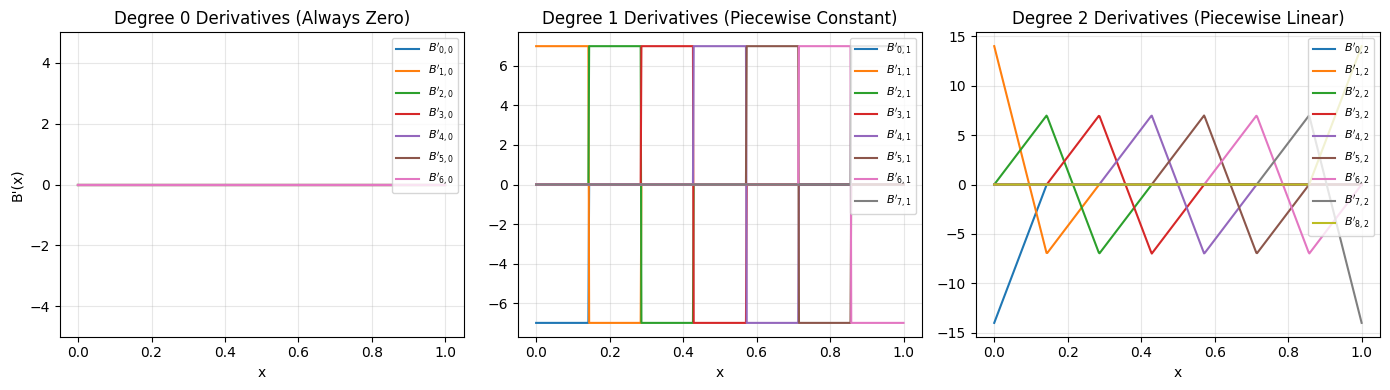

In [23]:
# Evaluate derivatives of all bases
dB0 = basis_0(x, derivative=True)  # Degree 0: derivative is zero everywhere (piecewise constant)
dB1 = basis_1(x, derivative=True)  # Degree 1: piecewise constant derivative
dB2 = basis_2(x, derivative=True)  # Degree 2: piecewise linear derivative

# Create 3 subplots for derivatives
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot degree 0 derivatives
for i in range(dB0.shape[0]):
    axes[0].plot(x.numpy(), dB0[i].numpy(), label=f"$B'_{{{i},0}}$")
axes[0].set_title("Degree 0 Derivatives (Always Zero)")
axes[0].set_xlabel('x')
axes[0].set_ylabel("B'(x)")
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylim(-5, 5)

# Plot degree 1 derivatives
for i in range(dB1.shape[0]):
    axes[1].plot(x.numpy(), dB1[i].numpy(), label=f"$B'_{{{i},1}}$")
axes[1].set_title("Degree 1 Derivatives (Piecewise Constant)")
axes[1].set_xlabel('x')
axes[1].legend(loc='upper right', fontsize=8)

# Plot degree 2 derivatives
for i in range(dB2.shape[0]):
    axes[2].plot(x.numpy(), dB2[i].numpy(), label=f"$B'_{{{i},2}}$")
axes[2].set_title("Degree 2 Derivatives (Piecewise Linear)")
axes[2].set_xlabel('x')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


## Boundary Modes: Zero Boundaries and Unbounded Domains

By default the basis is **clamped**: the boundary knots are repeated and the first/last basis functions reach $1$ at the boundary. Two additional per-side modes are available through the `bc=(left, right)` argument:

- **`"zero"`** — the basis function that is nonzero at that boundary is omitted, so every function in the span vanishes there (useful for densities or Dirichlet boundary conditions). The dimension `n` decreases by one.
- **`"decay"`** — the domain becomes unbounded on that side. The knot vector is extended with `deg` phantom knots and the basis functions crossing the boundary are continued by smooth tails
$$q_i(x)\, e^{-\lambda |x - b|},$$
where $q_i$ is a polynomial of degree $\mathrm{deg}-1$ matched in value and the first $\mathrm{deg}-1$ derivatives: the basis is $C^{\mathrm{deg}-1}$ on the whole unbounded domain. The decay rate $\lambda$ can be set via `decay_rate` (default: $\mathrm{deg}/h$ with $h$ the adjacent knot spacing). Crossing functions whose **center (Greville point) would fall outside the domain are dropped**, so the outermost retained function peaks at the boundary and decays monotonically past it — no redundant bump in the tail.

The interpolating points adapt automatically: for a `"zero"` side the boundary point is dropped, and for a `"decay"` side the out-of-domain points are dropped so all interpolating points stay within $[a, b]$ (the outermost sits exactly at the boundary). Integration weights include the analytic tail mass, so normalization over the unbounded domain works out of the box.

Zero-left basis: BSplineBasis(n=8, deg=2, interval=(0.0, 1.0), bc=('zero', 'clamped'))
(the clamped basis on the same knots would have n=9)


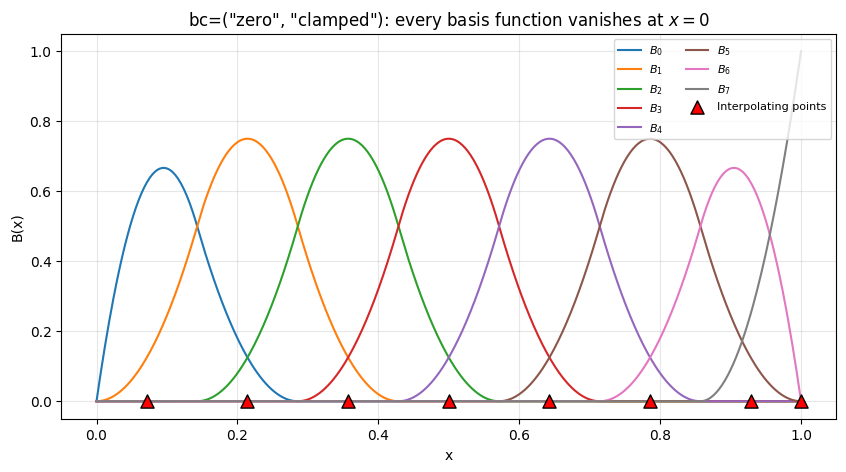

In [24]:
# --- Example 1: zero boundary at the left end ---
knots = torch.linspace(0, 1, 8)
basis_zero = BSplineBasis(knots, deg=2, bc=("zero", "clamped"))
print(f"Zero-left basis: {basis_zero}")
print(f"(the clamped basis on the same knots would have n={len(knots) + 2 - 1})")

x = torch.linspace(0, 1, 500, dtype=torch.float64)
B_zero = basis_zero(x)
pts_zero, _ = basis_zero.interpolating_points()

plt.figure(figsize=(10, 5))
for i in range(basis_zero.n):
    plt.plot(x.numpy(), B_zero[i].numpy(), label=f'$B_{{{i}}}$')
plt.scatter(pts_zero.numpy(), torch.zeros_like(pts_zero).numpy(), s=90, c='red', marker='^',
            zorder=5, edgecolors='black', label='Interpolating points')
plt.title('bc=("zero", "clamped"): every basis function vanishes at $x=0$')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()

Decay-right basis: BSplineBasis(n=5, deg=2, interval=(0.0, 2.0), bc=('clamped', 'decay'), decay_rate=(None, 4.0))
Integration weights sum: 2.041667 (interval length 2 plus the analytic tail mass)
Interpolating points: [0.   0.25 0.75 1.25 1.75]  <- last point sits at b=2, none beyond
Matrix condition number: 2.08


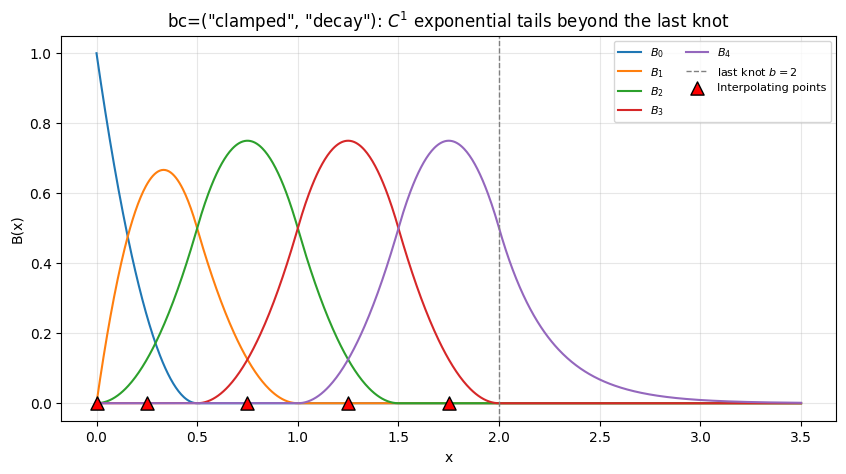

In [25]:
# --- Example 2: unbounded domain to the right (smooth exponential tails) ---
knots_d = torch.linspace(0, 2, 5)  # wide spacing h=0.5 so the tails are clearly visible
basis_decay = BSplineBasis(knots_d, deg=2, bc=("clamped", "decay"))
print(f"Decay-right basis: {basis_decay}")
print(f"Integration weights sum: {basis_decay.integration_weights().sum().item():.6f} "
      f"(interval length 2 plus the analytic tail mass)")

x_ext = torch.linspace(0, 3.5, 800, dtype=torch.float64)
B_decay = basis_decay(x_ext)
pts_decay, M_decay = basis_decay.interpolating_points()
print(f"Interpolating points: {pts_decay.numpy().round(4)}  <- last point sits at b=2, none beyond")
print(f"Matrix condition number: {torch.linalg.cond(M_decay):.2f}")

plt.figure(figsize=(10, 5))
for i in range(basis_decay.n):
    plt.plot(x_ext.numpy(), B_decay[i].numpy(), label=f'$B_{{{i}}}$')
plt.axvline(2.0, color='gray', linestyle='--', linewidth=1, label='last knot $b=2$')
plt.scatter(pts_decay.numpy(), torch.zeros_like(pts_decay).numpy(), s=90, c='red', marker='^',
            zorder=5, edgecolors='black', label='Interpolating points')
plt.title('bc=("clamped", "decay"): $C^{1}$ exponential tails beyond the last knot')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()

PDF-style basis: BSplineBasis(n=10, deg=3, interval=(0.0, 3.0), bc=('zero', 'decay'), decay_rate=(None, 9.000002145767724))


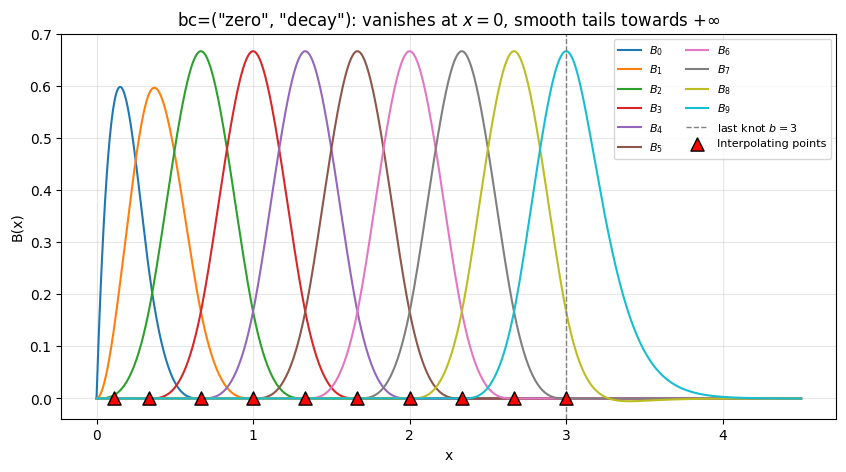

In [26]:
# --- Example 3: combination for densities on [0, inf): zero at 0, unbounded right ---
# Cubic (deg=3): the last retained function peaks exactly at b and decays monotonically,
# with no redundant bump past b (the out-of-domain crossing functions are dropped).
knots_pdf = torch.linspace(0, 3, 10)
basis_pdf = BSplineBasis(knots_pdf, deg=3, bc=("zero", "decay"))
print(f"PDF-style basis: {basis_pdf}")

x_pdf = torch.linspace(0, 4.5, 900, dtype=torch.float64)
B_pdf = basis_pdf(x_pdf)
pts_pdf, _ = basis_pdf.interpolating_points()

plt.figure(figsize=(10, 5))
for i in range(basis_pdf.n):
    plt.plot(x_pdf.numpy(), B_pdf[i].numpy(), label=f'$B_{{{i}}}$')
plt.axvline(3.0, color='gray', linestyle='--', linewidth=1, label='last knot $b=3$')
plt.scatter(pts_pdf.numpy(), torch.zeros_like(pts_pdf).numpy(), s=90, c='red', marker='^',
            zorder=5, edgecolors='black', label='Interpolating points')
plt.title('bc=("zero", "decay"): vanishes at $x=0$, smooth tails towards $+\\infty$')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()

# Gaussian Basis Functions

The `GaussianBasis` class implements a basis of Gaussian functions centered at the knots.
$$ \phi_i(x) = \exp\left(-\frac{(x - \mu_i)^2}{2\sigma_i^2}\right) $$
where $\mu_i$ are the knots and $\sigma_i$ determines the width.

In [27]:
from torchtt.functional import GaussianBasis

# Create Gaussian basis
knots = torch.linspace(0, 1, 10)
gaussian_basis = GaussianBasis(knots, delta_overlap=1)

print(f"Gaussian Basis: {gaussian_basis}")

Gaussian Basis: GaussianBasis(n=10, delta_overlap=1)


<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_817618/3916280675.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x.numpy(), B_gauss[i].numpy(), label=f'$\phi_{{{i}}}$')
/tmp/ipykernel_817618/3916280675.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi(x)$')


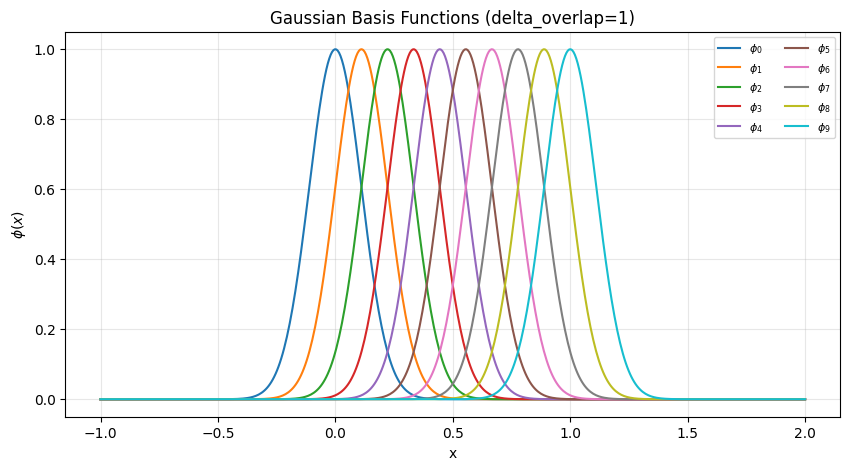

In [28]:
# Evaluate and plot
x = torch.linspace(-1, 2, 500, dtype=torch.float64)
B_gauss = gaussian_basis(x)

plt.figure(figsize=(10, 5))
for i in range(B_gauss.shape[0]):
    plt.plot(x.numpy(), B_gauss[i].numpy(), label=f'$\phi_{{{i}}}$')

plt.title('Gaussian Basis Functions (delta_overlap=1)')
plt.xlabel('x')
plt.ylabel('$\phi(x)$')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()